Dit script bevat een analyse voor AHN data 
 

In [83]:
import pandas as pd
import rioxarray

In [103]:
import geopandas as gpd
import pyogrio
from shapely.geometry import box
import fiona
import numpy as np

# Load raster file

In [85]:
ahn3_10hn2_raster = rioxarray.open_rasterio("data//Basisbestanden//AHN3_DTM_05//M_10HN2.TIF")

In [86]:
print(ahn3_10hn2_raster)

<xarray.DataArray (band: 1, y: 12500, x: 10000)> Size: 500MB
[125000000 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 80kB 1.75e+05 1.75e+05 1.75e+05 ... 1.8e+05 1.8e+05
  * y            (y) float64 100kB 5.625e+05 5.625e+05 ... 5.563e+05 5.563e+05
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Point
    _FillValue:              3.4028235e+38
    scale_factor:            1.0
    add_offset:              0.0
    units:                   metre


In [87]:
ahn3_10hn2_raster.values

array([[[-4.9199891e-01, -5.0099999e-01, -4.9733514e-01, ...,
          3.4028235e+38,  3.4028235e+38,  3.4028235e+38],
        [-5.1899999e-01, -5.0200111e-01, -4.6700105e-01, ...,
          3.4028235e+38,  3.4028235e+38,  3.4028235e+38],
        [-5.2133304e-01, -5.0699878e-01, -4.9349990e-01, ...,
          3.4028235e+38,  3.4028235e+38,  3.4028235e+38],
        ...,
        [-5.4775220e-01, -5.5867022e-01, -5.6800127e-01, ...,
         -8.1633753e-01, -8.2150102e-01, -8.2900226e-01],
        [-5.4824656e-01, -5.7000089e-01, -5.3799725e-01, ...,
         -8.2199639e-01, -8.3433110e-01, -8.2966721e-01],
        [-5.4800510e-01, -5.6066781e-01, -5.6533009e-01, ...,
         -8.3100152e-01, -8.2200193e-01, -8.2600302e-01]]],
      shape=(1, 12500, 10000), dtype=float32)

In [ ]:
ahn3_10hn2_raster.plot()

# Load vector data

In [88]:
brp_path = 'data//Basisbestanden//brpgewaspercelen_definitief_2025.gpkg'

In [89]:
brp = gpd.read_file(brp_path)

c:\anaconda\envs\geospatial\lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


In [90]:
layers = fiona.listlayers(brp_path)

In [91]:
print(layers)

['brp_gewas']


In [92]:
bladwijzer = gpd.read_file('data//Basisbestanden//bladwijzer_AHN.gpkg')

In [ ]:
bladwijzer.head()

In [93]:
blw_ahn3_10hn2 = bladwijzer.loc[bladwijzer['AHN']=='10HN2']

<Axes: >

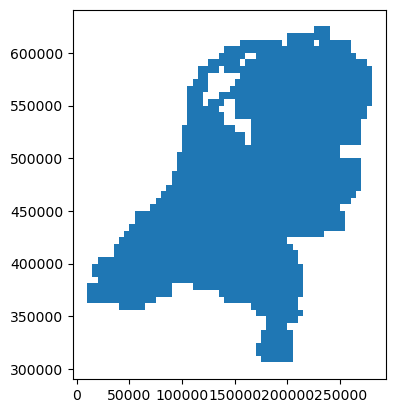

In [94]:
bladwijzer.plot()

In [95]:
xmin, ymin, xmax, ymax = blw_ahn3_10hn2.total_bounds
bbox = (xmin, ymin, xmax, ymax)

In [96]:
brp_section = pyogrio.read_dataframe(
    brp_path,
    layer="brp_gewas",
    bbox=bbox
)

c:\anaconda\envs\geospatial\lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


In [97]:
bbox

(np.float64(175000.0),
 np.float64(556250.0),
 np.float64(180000.0),
 np.float64(562500.0))

In [98]:
brp_section.head()

,category,gewas,gewascode,jaar,status,geometry
0,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((175035.512 561908.824, 175042.212 56..."
1,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((175022.479 561925.583, 175022.921 56..."
2,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((175000.139 562013.528, 174998.965 56..."
3,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((175147.566 561888.736, 175149.422 56..."
4,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((175028.623 561931.376, 175029.007 56..."


<Axes: >

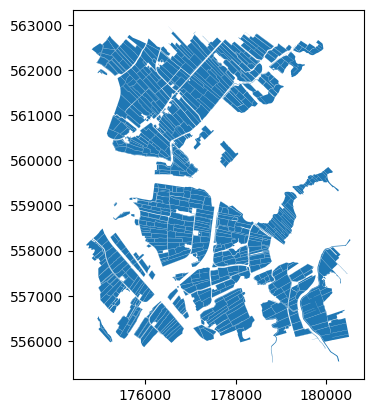

In [99]:
brp_section.plot()

In [100]:
bbox_geom = gpd.GeoDataFrame(
    geometry=[box(*bbox)],
    crs=brp_section.crs
)

In [101]:
brp_clipped = gpd.clip(brp_section, bbox_geom)

<Axes: >

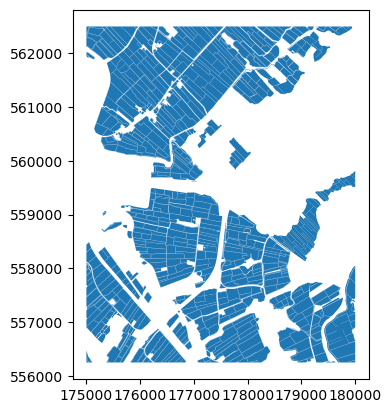

In [102]:
brp_clipped.plot()

In [107]:
# Example: dem = rxr.open_rasterio("dem.tif", masked=True).squeeze()
# If your DEM has a band dimension, remove it:
ahn3_10hn2_raster = ahn3_10hn2_raster.squeeze()


c:\anaconda\envs\geospatial\lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: overflow encountered in subtract
  resdat -= vmin


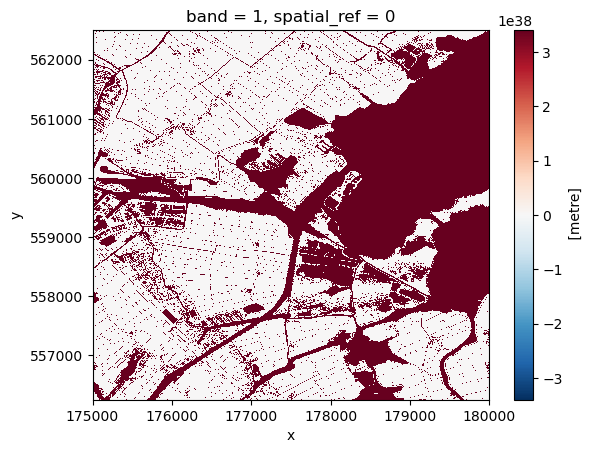

In [108]:
ahn3_10hn2_raster.plot()

In [109]:
# Get resolution
xres, yres = ahn3_10hn2_raster.rio.resolution()
xres = abs(xres)
yres = abs(yres)

# Calculate gradient
dz_dy, dz_dx = np.gradient(ahn3_10hn2_raster.values, yres, xres)

# Slope in degrees
slope_deg = np.degrees(
    np.arctan(
        np.sqrt(dz_dx**2 + dz_dy**2)
    )
)

# Convert back to xarray DataArray with same coords/metadata
slope = ahn3_10hn2_raster.copy(data=slope_deg.astype("float32"))
slope.name = "slope_degrees"

# Preserve CRS and transform
slope = slope.rio.write_crs(ahn3_10hn2_raster.rio.crs)

# Save
slope.rio.to_raster("slope_degrees.tif")

c:\anaconda\envs\geospatial\lib\site-packages\numpy\lib\_function_base_impl.py:1307: RuntimeWarning: overflow encountered in divide
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
c:\anaconda\envs\geospatial\lib\site-packages\numpy\lib\_function_base_impl.py:1314: RuntimeWarning: overflow encountered in divide
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
C:\Users\mtmde\AppData\Local\Temp\ipykernel_10896\3925876684.py:12: RuntimeWarning: overflow encountered in square
  np.sqrt(dz_dx**2 + dz_dy**2)


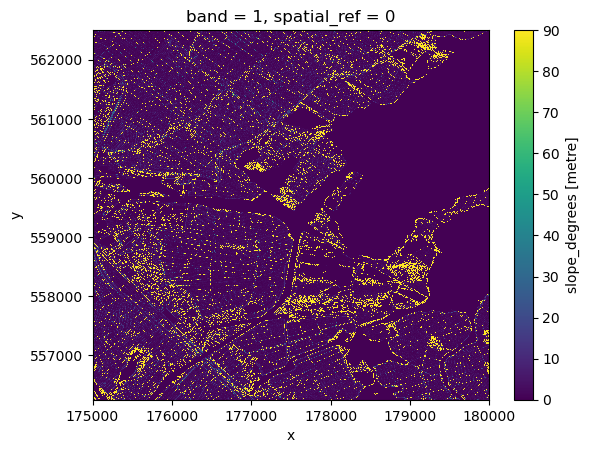

In [110]:
slope.plot()